# In this notebook, we get the non-trivial solutions for $\left\{(\alpha, \beta):\ L_{\beta G}\left(T(\alpha G, l)\right) - \mathcal{H}(\beta G) = 0\right\}$

We find nontrivial $f_{G, T}(\alpha)$ such that $$L_{f(\alpha) G}\left(T(\alpha G, l)\right) - \mathcal{H}(f(\alpha) G) = 0$$

We note that $f(\alpha) = 0$ is a trivial solution.
- The way we find the non-trivial part of the solution is empirical;
- and the approximated curve can be very noisy.
- But from the approximated curve, we can see that true curve is rather smooth.

We process the approximated curve and fit a polynomial as a better approximation to $f(\alpha)$.

In [3]:
import numpy as np
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [4]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


def remove_outliers(x, y, box_pts, z_value_cutoff):
    y_smooth = smooth(y, box_pts)
    
    diff = y_smooth - y
    mean = np.mean(diff)
    std = np.std(diff)
    
    outlier_idx = []
    for i, d in enumerate(diff):
        z_value = (d - mean) / std
        if abs(z_value) > 2:
            outlier_idx.append(i)
    
    cleaned_x = np.delete(x, outlier_idx)
    cleaned_y = np.delete(y, outlier_idx)
    
    return cleaned_x, cleaned_y

In [14]:
folder = '/home/yhuang10/D3M/zutil_/llk_matrices'
length = 1000
num_samples = 100

In [23]:
def analyze_result(filename):
    
    data = np.genfromtxt(filename)
    X, er, llk = data[0], data[1], data[2:]

    X_0 = []
    for i in range(len(X)):
        vec = abs(llk[i] - er)
        idx = np.argsort(vec)[:3]
        x = X[idx]
        idx_largest_dev = np.argmax(abs(x))
        X_0.append(x[idx_largest_dev])

    cleaned_x, cleaned_y = remove_outliers(X, X_0, 5, 2)
    f = np.poly1d(np.polyfit(cleaned_x, cleaned_y, 3))  ###################### We find the f here ########################
    
    # Plot
    plt.figure(figsize=(6, 6))
    plt.xlabel(r'$\alpha$', fontsize=16)
    plt.ylabel(r'$\beta$', fontsize=16, rotation=0)

    plt.plot(X, X_0, 'g-', label='original')
    plt.plot(cleaned_x, cleaned_y, '-', label='outlier removed')
    plt.plot(X, f(X), 'r--', label=r'poly fitted $f(\alpha)$')
    
    ########### plot the diagonal to see the solution for f(a) = a ############
    # plt.plot(X, X, 'k', label='diagonal')
    ########### plot the diagonal to see the solution for f(a) = a ############
    
    plt.title('Non-trival Solution, Cleaned, and Fitted', fontsize=15)

    plt.legend(fontsize=15)
    plt.show()
    
    return X, X_0, er, f

In [25]:
! ls /home/yhuang10/D3M/zutil_/cfgfiles/

PFSA_3_3.cfg   PFSA_M4_5.cfg	XPFSA_2_3_1.cfg  XPFSA_2_4_7.cfg
PFSA_M2_0.cfg  PFSA_M4_6.cfg	XPFSA_2_3_2.cfg  XPFSA_2_4_8.cfg
PFSA_M2_1.cfg  PFSA_M4_7.cfg	XPFSA_2_3_3.cfg  XPFSA_2_4_9.cfg
PFSA_M2_2.cfg  PFSA_M4_8.cfg	XPFSA_2_3_4.cfg  XPFSA_2_5_0.cfg
PFSA_M2_3.cfg  PFSA_M4_9.cfg	XPFSA_2_3_5.cfg  XPFSA_2_5_1.cfg
PFSA_M2_4.cfg  XPFSA_2_2_0.cfg	XPFSA_2_3_6.cfg  XPFSA_2_5_2.cfg
PFSA_M2_5.cfg  XPFSA_2_2_1.cfg	XPFSA_2_3_7.cfg  XPFSA_2_5_3.cfg
PFSA_M2_6.cfg  XPFSA_2_2_2.cfg	XPFSA_2_3_8.cfg  XPFSA_2_5_4.cfg
PFSA_M2_7.cfg  XPFSA_2_2_3.cfg	XPFSA_2_3_9.cfg  XPFSA_2_5_5.cfg
PFSA_M2_8.cfg  XPFSA_2_2_4.cfg	XPFSA_2_4_0.cfg  XPFSA_2_5_6.cfg
PFSA_M2_9.cfg  XPFSA_2_2_5.cfg	XPFSA_2_4_1.cfg  XPFSA_2_5_7.cfg
PFSA_M4_0.cfg  XPFSA_2_2_6.cfg	XPFSA_2_4_2.cfg  XPFSA_2_5_8.cfg
PFSA_M4_1.cfg  XPFSA_2_2_7.cfg	XPFSA_2_4_3.cfg  XPFSA_2_5_9.cfg
PFSA_M4_2.cfg  XPFSA_2_2_8.cfg	XPFSA_2_4_4.cfg  XPFSA_3_3_identity.cfg
PFSA_M4_3.cfg  XPFSA_2_2_9.cfg	XPFSA_2_4_5.cfg  XPFSA_3_3_oppo.cfg
PFSA_M4_4.cfg  XPFSA_2_3_0.cfg	XPFSA_2_4


############## DESCRIPTION of transducer START ##############
number of states = 3
alphabet size = 2

aut:
	0 2 
	2 1 
	0 1 

pitilde:
	0.5 0.5 
	0.5 0.5 
	0.5 0.5 


output probability:
	0.142857 0.857143 
	0.583333 0.416667 
	0.9 0.1 


Stationary Distribution on States:
	0.333356 0.333356 0.333289 

Stationary Distribution on Symbols:
	0.5 0.5 

Entropy rate = 1.

Phase matrix Omega:
	-0.146785 0.146785 
	0.146856 -0.146856 
############### DESCRIPTION of transducer END ###############



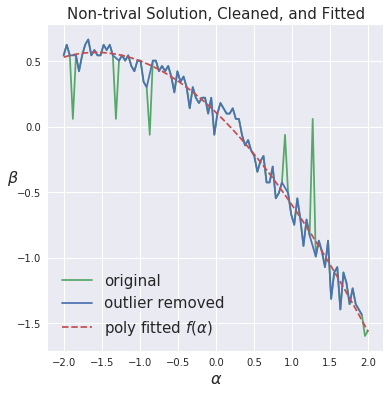

In [27]:
# to use other pfsa and xpfsa cfgfiles, write your own and save to the cfgfiles folder

# xpfsa, pfsa = "XPFSA_2_3_2", "PFSA_M2_3"
xpfsa, pfsa = "XPFSA_2_3_2", "PFSA_M2_0"
# xpfsa, pfsa = "XPFSA_2_3_2", "PFSA_M4_9"

pfsa_filename = "./cfgfiles/{}.cfg".format(pfsa)
xpfsa_filename = "./cfgfiles/{}.cfg".format(xpfsa)

# The phase matrix is show at the bottom of output of the following command
! /home/yhuang10/D3M/zutil_/bin_practice/test_zbase_llk -p $pfsa_filename -x $xpfsa_filename -l $length -n $num_samples

filename = '{}/llk-{}-{}-{}-{}'.format(folder, pfsa, xpfsa, length, num_samples)
Alpha, Beta, er, f = analyze_result(filename)